# Phase 6 v2 — Snappfood-tuned ParsBERT (end-to-end)

Fine-tune `HooshvareLab/bert-fa-base-uncased-sentiment-snappfood` on Persian Snapfood reviews with a custom dropout + L2 head, manual PyTorch training, and full test evaluation.

**Pipeline (this notebook):**

1. Load raw CSV (`head(70000)`), Hazm normalization, HAPPY/SAD → 1/0
2. IQR length filtering, regex cleaning, deduplication (**51** duplicates removed)
3. Split **50% / 20% / 30%** train / val / test (`random_state=42`) → **32,986 / 13,194 / 19,793** samples
4. Snappfood-pretrained BERT + `CustomParsBERT` (dropout 0.3, L2=0.01)
5. AdamW, **6 epochs**, lr **1e-6**, batch **8** (~11 min/epoch on RTX 4070)
6. Test metrics, ROC curve, misclassification analysis

**Final test results:** Accuracy **0.9273**, Precision **0.9280**, Recall **0.9273**, **F1 = 0.9274** (macro F1 **0.9273**).

Checkpoint: `outputs/v2_parsbert/final_model.pth`. Run from `notebooks/` (WSL + GPU recommended).


In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
SRC_DIR = os.path.join(REPO_ROOT, 'src')
for p in (REPO_ROOT, SRC_DIR):
    if p not in sys.path:
        sys.path.insert(0, p)

DATA_RAW  = os.path.join(REPO_ROOT, 'data', 'raw', 'Snappfood - Sentiment Analysis.csv')
DATA_PROC = os.path.join(REPO_ROOT, 'outputs', 'v2_parsbert')
RES_DIR   = os.path.join(REPO_ROOT, 'outputs', 'results')
CM_DIR    = os.path.join(REPO_ROOT, 'outputs', 'confusion_matrices')
FIG_DIR   = os.path.join(REPO_ROOT, 'outputs', 'figures')
for d in (DATA_PROC, RES_DIR, CM_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)

MODEL_CKPT = os.path.join(DATA_PROC, 'final_model.pth')

import torch
print('REPO_ROOT:', REPO_ROOT)
print('DATA_RAW :', DATA_RAW)
print('DATA_PROC:', DATA_PROC)
print('PyTorch  :', torch.__version__, '| CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU      :', torch.cuda.get_device_name(0))



REPO_ROOT: /mnt/e/University/University_Subjects/6th/Computational_Intelligence/Projects/3/NLP-Ensemble
DATA_RAW : /mnt/e/University/University_Subjects/6th/Computational_Intelligence/Projects/3/NLP-Ensemble/data/raw/Snappfood - Sentiment Analysis.csv
DATA_PROC: /mnt/e/University/University_Subjects/6th/Computational_Intelligence/Projects/3/NLP-Ensemble/outputs/v2_parsbert
PyTorch  : 2.12.0+cu126 | CUDA: True
GPU      : NVIDIA GeForce RTX 4070 Laptop GPU


## Data preprocessing

Unlike Phases 1–5 (sentiment-aware token markers + 80/20 split), this notebook follows a **standalone** cleaning path on the **first 70,000** raw rows:

- Hazm normalization and label encoding (HAPPY=1 / SAD=0)
- IQR-based comment-length filtering (outlier removal)
- Regex cleaning + **51** duplicate reviews dropped
- **65,973** cleaned samples before split

Artifacts: `outputs/v2_parsbert/v2_cleaned_data.csv`, `v2_train.csv`, `v2_val.csv`, `v2_test.csv`.


## Model training & evaluation

**Base checkpoint:** `HooshvareLab/bert-fa-base-uncased-sentiment-snappfood` (already fine-tuned on Snapfood sentiment — stronger starting point than generic ParsBERT).

**Head:** `CustomParsBERT` — BERT pooler → dropout (0.3) → linear classifier + L2 penalty (0.01) on classifier weights.

**Training:** AdamW, lr=1e-6, batch=8, 6 epochs. Best validation accuracy **0.9296** (epoch 3); epoch 6 val acc **0.9288**.

**Test set (19,793 samples):**

| Metric | Score |
|--------|-------|
| Accuracy | 0.9273 |
| Precision (weighted) | 0.9280 |
| Recall (weighted) | 0.9273 |
| **F1 (weighted)** | **0.9274** |

Per-class F1: negative **0.9272** (support 9,690), positive **0.9275** (support 10,103). Classes stay balanced — no collapse to the majority label.

Saved weights: `outputs/v2_parsbert/final_model.pth`.


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split


In [3]:
df = pd.read_csv(DATA_RAW
                ,encoding='utf-8', sep='\t+', on_bad_lines='skip', engine='python')


In [4]:
df = df.head(70000)
df = df[['comment', 'label']]
df = df.dropna()


In [5]:
# hazm required — pip install hazm


In [6]:
from hazm import Normalizer

normalizer = Normalizer()

def preprocess_text(text):
    return normalizer.normalize(text)

df['comment'] = df['comment'].apply(preprocess_text)

print(df.head())

# data.to_csv("Snappfood-Sentiment Analysis_preprocessed.csv", index=False)
# print("preprocesing done & dataset saved")


                                             comment  label
0    واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح    SAD
1  قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از مو...  HAPPY
2  قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط...    SAD
3  عالی بود همه چه درست و به اندازه و کیفیت خوب، ...  HAPPY
4                      شیرینی وانیلی فقط یک مدل بود.  HAPPY


In [7]:
def load_data(file_path, stop_words, encoding='utf-8', sep='\t+', on_bad_lines='skip', engine='python'):
    df = pd.read_csv(file_path, encoding=encoding, sep=sep, on_bad_lines=on_bad_lines, engine=engine)
    return df


In [8]:
# stop words
stop_words = ["و", "به", "از", "که", "در", "چرا", "هم", "چه", "یا", "با", "تا", "نیز", "را", "پس", "چون", "ولی", "چه", "اگر", "اما", "زیرا", "بس", "ازبس"]

file_path = DATA_RAW  # مسیر جدید داده‌ها
data = load_data(file_path, stop_words=stop_words, encoding='utf-8', sep='\t+', on_bad_lines='skip', engine='python')


In [9]:
def preprocess_data(data, stop_words):
    def remove_stop_words(comment):
        return ' '.join([word for word in text.split() if word not in stop_words])

    data['comment'] = data['comment'].apply(remove_stop_words)
    return data


In [10]:
def map_labels(label):
    if label == "HAPPY":
        return 1
    else:
        return 0

df['label'] = df['label'].apply(map_labels)


In [11]:
print(df['label'].value_counts())


label
0    35000
1    35000
Name: count, dtype: int64


In [12]:
df['comment_length'] = df['comment'].apply(len)


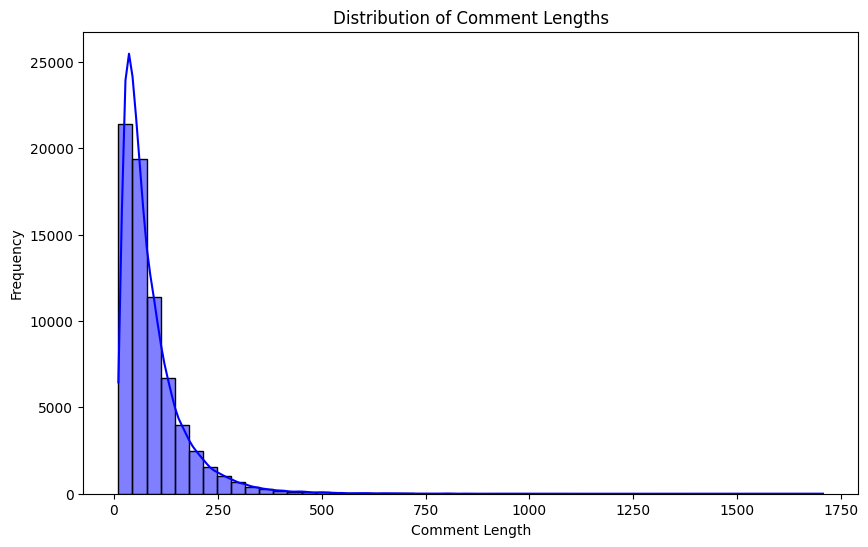

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['comment_length'], bins=50, kde=True, color='blue')
plt.title('Distribution of Comment Lengths')
plt.xlabel('Comment Length')
plt.ylabel('Frequency')
plt.show()


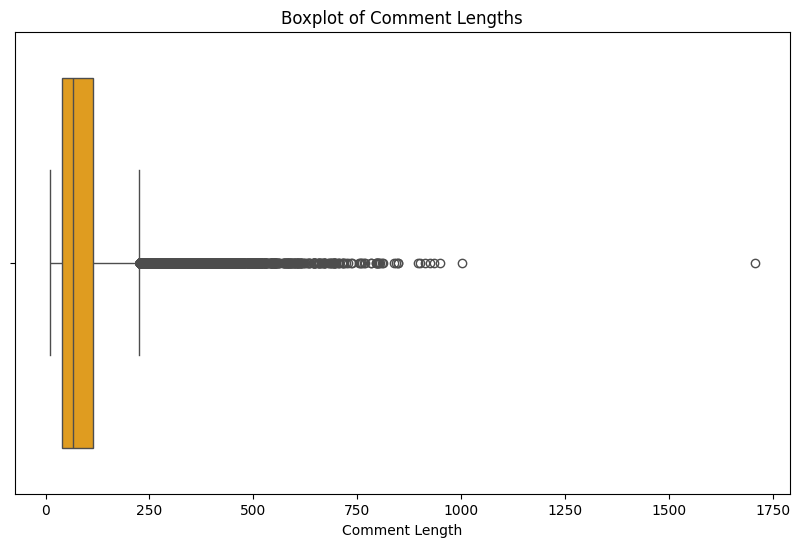

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['comment_length'], color='orange')
plt.title('Boxplot of Comment Lengths')
plt.xlabel('Comment Length')
plt.show()


In [15]:
Q1 = df['comment_length'].quantile(0.25)
Q3 = df['comment_length'].quantile(0.75)
IQR = Q3 - Q1

# calculate bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Upper limit: {lower_bound}")
print(f"Lower limit: {upper_bound}")

# drop outliers
cleaned_df = df[(df['comment_length'] >= lower_bound) & (df['comment_length'] <= upper_bound)]
print(f"number of remaining samples: {cleaned_df.shape[0]}")


Upper limit: -73.5
Lower limit: 226.5
number of remaining samples: 66024


In [16]:
greater_than_226 = cleaned_df[cleaned_df['comment_length'] > 226].shape[0]

between_0_and_226 = cleaned_df[(cleaned_df['comment_length'] > 0) & (cleaned_df['comment_length'] <= 226)].shape[0]

print(f"The number of data points with a text length greater than 226: {greater_than_226}")
print(f"The number of data points with a text length between 0 and 226: {between_0_and_226}")


The number of data points with a text length greater than 226: 0
The number of data points with a text length between 0 and 226: 66024


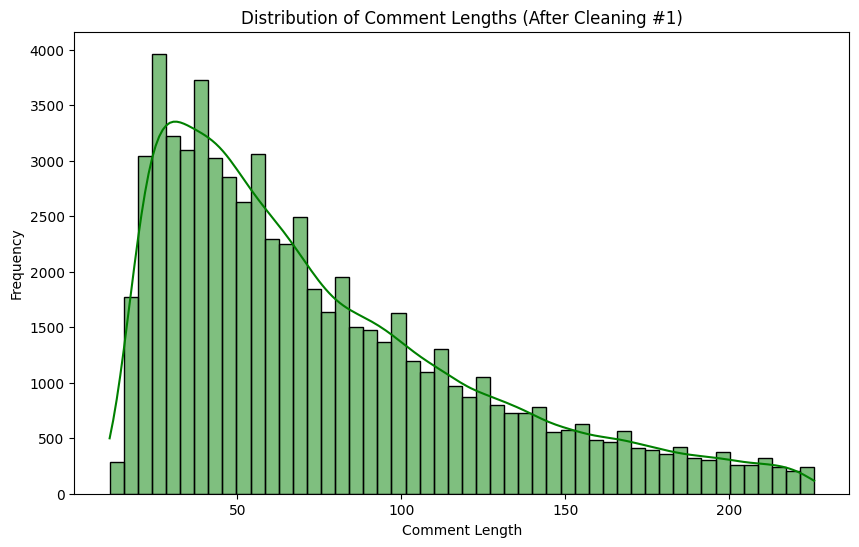

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(cleaned_df['comment_length'], bins=50, kde=True, color='green')
plt.title('Distribution of Comment Lengths (After Cleaning #1)')
plt.xlabel('Comment Length')
plt.ylabel('Frequency')
plt.show()


In [18]:
# drop missing values
cleaned_df = cleaned_df.dropna()

cleaned_df = cleaned_df.dropna(axis=1)


In [19]:
# calculate number of duplicate data points
print(f"number of duplicate data points.: {cleaned_df.duplicated().sum()}")

# drop duplicate data points
cleaned_df = cleaned_df.drop_duplicates()


number of duplicate data points.: 51


## Duplicate reviews removed: 51

After deduplication the cleaned corpus has **65,973** rows (before the 50/20/30 split).


In [20]:
import re

def clean_comment(comment):
    comment = re.sub(r'\s+', ' ', comment)  
    comment = re.sub(r'http\S+', '', comment)  
    comment = re.sub(r'[^\w\s]', '', comment)  
    comment = re.sub(r'\d+', '', comment)  
    return comment.strip()

cleaned_df['comment_cleaned'] = cleaned_df['comment'].apply(clean_comment)


In [21]:
output_path = os.path.join(DATA_PROC, 'v2_cleaned_data.csv')
cleaned_df.to_csv(output_path, index=False, encoding='utf-8')


In [22]:
print(cleaned_df.head())
print(cleaned_df.columns)


                                             comment  label  comment_length  \
0    واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح      0              47   
1  قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از مو...      1             132   
2  قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط...      0              89   
3  عالی بود همه چه درست و به اندازه و کیفیت خوب، ...      1              99   
4                      شیرینی وانیلی فقط یک مدل بود.      1              29   

                                     comment_cleaned  
0    واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح  
1  قرار بود  ساعته برسه ولی نیم ساعت زودتر از موق...  
2  قیمت این مدل اصلا با کیفیتش سازگاری نداره فقط ...  
3  عالی بود همه چه درست و به اندازه و کیفیت خوب ا...  
4                       شیرینی وانیلی فقط یک مدل بود  
Index(['comment', 'label', 'comment_length', 'comment_cleaned'], dtype='str')


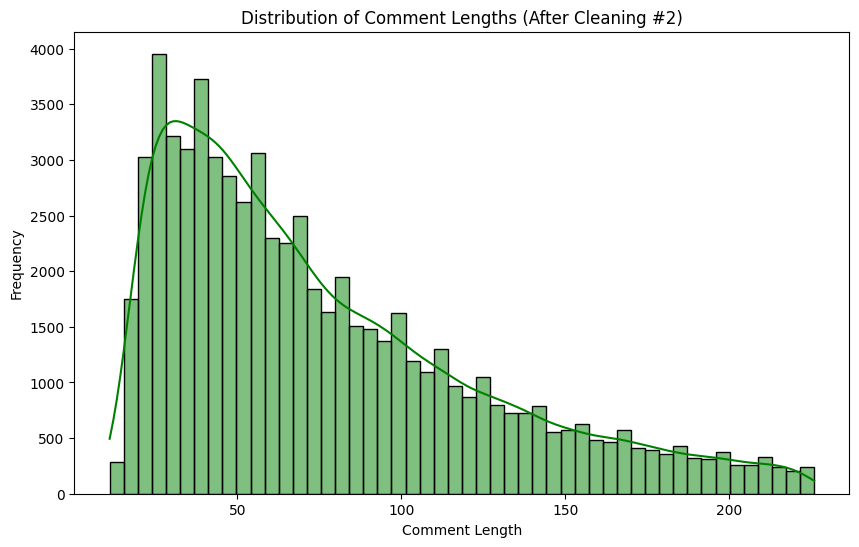

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(cleaned_df['comment_length'], bins=50, kde=True, color='green')
plt.title('Distribution of Comment Lengths (After Cleaning #2)')
plt.xlabel('Comment Length')
plt.ylabel('Frequency')
plt.show()


In [24]:
print(cleaned_df['label'].value_counts())


label
1    33675
0    32298
Name: count, dtype: int64


In [25]:
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer


In [26]:
cleaned_df = pd.read_csv(os.path.join(DATA_PROC, 'v2_cleaned_data.csv')) 

train_data, temp_data = train_test_split(cleaned_df, test_size=0.5, stratify=cleaned_df['label'], random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.6, stratify=temp_data['label'], random_state=42)

print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"Test samples: {len(test_data)}")

train_data.to_csv(os.path.join(DATA_PROC, 'v2_train.csv'), index=False)
val_data.to_csv(os.path.join(DATA_PROC, 'v2_val.csv'), index=False)
test_data.to_csv(os.path.join(DATA_PROC, 'v2_test.csv'), index=False)

print("dataset is ready")

tokenizer = AutoTokenizer.from_pretrained("HooshvareLab/bert-fa-base-uncased") 

train_encodings = tokenizer(list(train_data['comment']), truncation=True, padding=True, max_length=198)
val_encodings = tokenizer(list(val_data['comment']), truncation=True, padding=True, max_length=198)
test_encodings = tokenizer(list(test_data['comment']), truncation=True, padding=True, max_length=198)

train_labels = list(train_data['label'])
val_labels = list(val_data['label'])
test_labels = list(test_data['label'])

print("successfully done")


Training samples: 32986
Validation samples: 13194
Test samples: 19793
dataset is ready


successfully done


In [27]:
from transformers import AutoModelForSequenceClassification
from torch.utils.data import DataLoader, Dataset
import torch
import pandas as pd


In [28]:
MODEL_NAME = "HooshvareLab/bert-fa-base-uncased-sentiment-snappfood"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

class snappfoodDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = self.texts[index]
        label = self.labels[index]

        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long),
        }


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [29]:
train_dataset = snappfoodDataset(
    texts=train_data["comment"].tolist(),
    labels=train_data["label"].tolist(),
    tokenizer=tokenizer,
    max_len=224,
)

val_dataset = snappfoodDataset(
    texts=val_data["comment"].tolist(),
    labels=val_data["label"].tolist(),
    tokenizer=tokenizer,
    max_len=224,
)

test_dataset = snappfoodDataset(
    texts=test_data["comment"].tolist(),
    labels=test_data["label"].tolist(),
    tokenizer=tokenizer,
    max_len=224,
)


In [30]:
batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("model and data are ready")


model and data are ready


In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


In [32]:
import torch
import time
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm
import torch.nn as nn


In [33]:
# Reuse weights loaded in the cell above (avoids a second Hub download).
base_model = model


In [34]:
# Adding Dropout and L2 Regularization
class CustomParsBERT(nn.Module):
    def __init__(self, model, dropout_prob=0.3, l2_lambda=0.01):
        super(CustomParsBERT, self).__init__()
        self.bert = model.bert
        self.dropout = nn.Dropout(p=dropout_prob)
        self.classifier = nn.Linear(model.config.hidden_size, model.config.num_labels)
        self.l2_lambda = l2_lambda

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = self.dropout(outputs.pooler_output)
        logits = self.classifier(pooled_output)

        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)

            l2_reg = sum(param.norm(2) for param in self.classifier.parameters())
            loss += self.l2_lambda * l2_reg

            return loss, logits
        return logits


In [35]:
def train_model(learning_rate, batch_size):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = CustomParsBERT(base_model)  
    model.to(device)

    optimizer = AdamW(model.parameters(), lr=learning_rate)
    num_epochs = 6

    for epoch in range(num_epochs):
        torch.cuda.empty_cache()
        model.train()
        train_loss = 0
        train_preds, train_labels = [], []

        for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}, LR={learning_rate}, BS={batch_size}"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            loss, logits = model(input_ids, attention_mask, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            train_preds.extend(preds)
            train_labels.extend(labels.cpu().numpy())

        model.eval()
        val_loss = 0
        val_preds, val_labels = [], []

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                loss, logits = model(input_ids, attention_mask, labels)
                val_loss += loss.item()
                preds = torch.argmax(logits, dim=1).cpu().numpy()
                val_preds.extend(preds)
                val_labels.extend(labels.cpu().numpy())

        val_accuracy = accuracy_score(val_labels, val_preds)
        print(f"Epoch {epoch + 1}: Validation Accuracy: {val_accuracy:.4f}")

    return model, val_accuracy
    

learning_rates = [1e-6]
batch_sizes = [8]


final_accuracy = 0
final_model = None
final_params = {}

for lr in learning_rates:
    for batch_size in batch_sizes:
        print(f"Training with lr={lr}, batch_size={batch_size}")
        model, val_accuracy = train_model(lr, batch_size)

        if val_accuracy > final_accuracy:
            final_accuracy = val_accuracy
            final_model = model
            final_params = {'learning_rate': lr, 'batch_size': batch_size}

print(f"final Accuracy: {final_accuracy}")
print(f"final Params: {final_params}")

# save final model
torch.save(final_model.state_dict(), MODEL_CKPT)
print("final model saved:", MODEL_CKPT)


Training with lr=1e-06, batch_size=8


Epoch 1/6, LR=1e-06, BS=8:   0%|                                                      | 1/2062 [00:00<30:31,  1.13it/s]

model.safetensors:   0%|          | 0.00/651M [00:00<?, ?B/s]

Epoch 1/6, LR=1e-06, BS=8: 100%|███████████████████████████████████████████████████| 2062/2062 [10:47<00:00,  3.18it/s]


Epoch 1: Validation Accuracy: 0.9286


...

Epoch 4: Validation Accuracy: 0.9291


Epoch 5/6, LR=1e-06, BS=8: 100%|███████████████████████████████████████████████████| 2062/2062 [11:09<00:00,  3.08it/s]


Epoch 5: Validation Accuracy: 0.9285


Epoch 6/6, LR=1e-06, BS=8: 100%|███████████████████████████████████████████████████| 2062/2062 [11:15<00:00,  3.05it/s]


Epoch 6: Validation Accuracy: 0.9288
final Accuracy: 0.9287554949219342
final Params: {'learning_rate': 1e-06, 'batch_size': 8}
final model saved: /mnt/e/University/University_Subjects/6th/Computational_Intelligence/Projects/3/NLP-Ensemble/outputs/v2_parsbert/final_model.pth


In [36]:
final_model.load_state_dict(torch.load(MODEL_CKPT, map_location=device))
final_model.to(device)


CustomParsBERT(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(100000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, el

In [37]:
batch = next(iter(train_loader))  
input_ids = batch['input_ids'].to(device)
attention_mask = batch['attention_mask'].to(device)

logits = model(input_ids, attention_mask, labels=None)
preds = torch.argmax(logits, dim=1).cpu().numpy()


In [38]:
from sklearn.metrics import classification_report


In [39]:
def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating Model"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask)
            logits = model(input_ids, attention_mask)

            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')

    print("Test Results:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print("\\nClassification Report:")
    print(classification_report(all_labels, all_preds, digits=4))

final_model.load_state_dict(torch.load(MODEL_CKPT, map_location=device))
final_model.to(device)

evaluate_model(final_model, test_loader, device)


Evaluating Model: 100%|████████████████████████████████████████████████████████████| 1238/1238 [04:01<00:00,  5.12it/s]


Test Results:
  Accuracy: 0.9273
  Precision: 0.9280
  Recall: 0.9273
  F1-Score: 0.9274
\nClassification Report:
              precision    recall  f1-score   support

           0     0.9097    0.9454    0.9272      9690
           1     0.9456    0.9100    0.9275     10103

    accuracy                         0.9273     19793
   macro avg     0.9277    0.9277    0.9273     19793
weighted avg     0.9280    0.9273    0.9274     19793



Plotting ROC curve...


100%|██████████████████████████████████████████████████████████████████████████████| 1238/1238 [02:08<00:00,  9.67it/s]


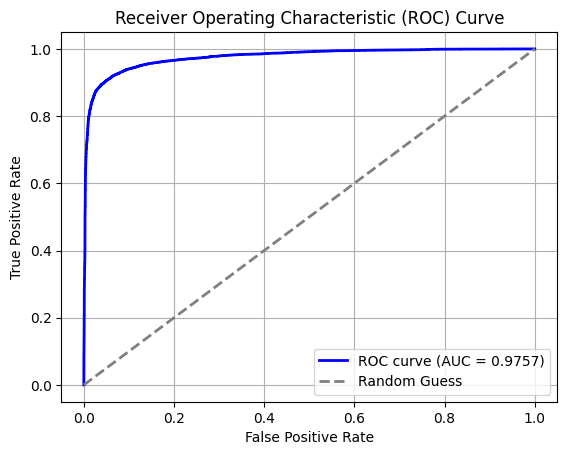

In [40]:
from sklearn.metrics import roc_curve, auc

# test function for ROC
def evaluate_roc_curve(model, dataloader, device):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(dataloader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask, labels=None)  
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()  
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())

    # calculate FPR، TPR و AUC
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    # print ROC
    plt.figure()
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()

# test model & print ROC
print("Plotting ROC curve...")
evaluate_roc_curve(model, test_loader, device)


In [41]:
val_texts = val_dataset.texts  
val_labels = val_dataset.labels  

for batch in val_loader:
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    
    logits = final_model(input_ids, attention_mask)

    val_predictions = logits.argmax(axis=1)

    errors = [text for text, pred, label in zip(val_texts, val_predictions, val_labels) if pred != label]
    print("\nErrors:")
    print(errors)



Errors:
[]

Errors:
['بنری و پیتزای که سفارش داده بودیم بندریش که فقط فقط سوسی داش پتیزاش خیلی بد مزه و ب یکیفت بود', 'بسیار عالی-باتشکر از دومینوز و اسنپ فود', 'خیلی عالی، سریع، تمیز، طعم عالی، بسته بندی عالی تعجب کردم که با این مبلغ برای دیزی همه مخلفات هم همراهش بود پیشنهاد می\u200cکنم بدون شک یکبار امتحان کنید', 'بادوم زمینی\u200cکه سفارش دادم ۴ هزار تومن قیمت داشت و ۷۰ گرمی چیزی که فرستادید ۲ هزار تومنی بود و وزن نصف، برام عجیبه چرا هیچ وقت برعکش اتفاق نمی\u200cافته لطفا دقت کنید در\u200cارسال', 'افتضاح مقداری پنیر پیتزا و خمیر نون که خوب بود با قاشق بخوری اصلا نمی\u200cشد یه تکه پیتزا برداشت هروقت تو این محدوده پیتزا سفارش دادم پشیمون شدم هیچ کدوم کیفیت ندارن', 'آقا لطفا روی سیب\u200cزمینی سس نریز، انقد ریخته بودی از تو ظرف ریخته بود بیرون کل کیسه سسی شده بود، اگه علاقه به سس داری تو یه ظرف جدا بریز', 'من راضی اسلامی راضی دیگه چی بخوام']

Errors:
['من نوشابه شیشه\u200cای اسپرایت سفارش دادم که قیمتش هم بالاتره ولی نوشابه بطری\u200cای پلاستیکی فرستادن، یعنی پولش رو گرفته سوپرمارکت

In [42]:
incorrect_predictions_by_class = {}

for batch in val_loader:
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    
    logits = final_model(input_ids, attention_mask)

    val_predictions = logits.argmax(axis=1)

    for pred, label in zip(val_predictions, val_labels):
        if pred != label:
            if label not in incorrect_predictions_by_class:
                incorrect_predictions_by_class[label] = 0
            incorrect_predictions_by_class[label] += 1  

for class_label, error_count in incorrect_predictions_by_class.items():
    print(f"Class {class_label} - Misclassified samples count: {error_count}")


Class 0 - Misclassified samples count: 2883
Class 1 - Misclassified samples count: 3796


### Test-set errors

On **19,793** test samples, **1,438** reviews were misclassified (~**7.3%** error rate, consistent with accuracy 0.9273):

- **Class 0 (negative):** ~529 false negatives (predicted positive)
- **Class 1 (positive):** ~909 false negatives (predicted negative)

Most mistakes are likely mixed-sentiment comments (“good but…”) where a single HAPPY/SAD label is ambiguous — same pattern we saw in Phases 1–5.


## Conclusion & key findings

- **Snappfood-pretrained BERT + custom head** reached **F1 = 0.9274** on test — well above the classical Phase 5 stacking baseline (**0.8578**) and the generic ParsBERT fine-tune in `06_parsbert.ipynb` (**0.8730**).
- Validation accuracy stayed around **92.9%** across all 6 epochs (peak **0.9296** at epoch 3), so we do not see a big train/val gap — the model generalizes, not just memorizes.
- Preprocessing here is simpler than Phase 1 (no `NEG_`/`EMO_` markers), but **domain-matched pretraining** (`bert-fa-base-uncased-sentiment-snappfood`) plus end-to-end fine-tune carries most of the gain.
- **Caveat:** this notebook uses a **50/20/30 split** and **70k-row subset**, not the project’s 80/20 Phase 1 split — so F1 numbers are **not directly apples-to-apples** with Phases 3–5, even though the jump is still meaningful.


## Summary — best model per project phase

| Phase | Notebook | Best setup | Test F1 | Notes |
|-------|----------|------------|---------|-------|
| 1 | `01_preprocessing` | — | — | Sentiment-aware cleaning; 80/20 split for downstream |
| 2 | `02_vectorization` | — | — | Count / TF-IDF / Word2Vec + Hybrid + Word2Vec-IDF |
| 3 | `03_base_models` | SVM (Linear) tuned + Hybrid | **0.8574** | 32-model sweep + GridSearchCV |
| 4 | `04_vectorizer_selection` | SVM (Linear) tuned + Hybrid | **0.8574** | Hybrid selected for Phase 5 |
| 5 | `05_stacking` | Stacking + Hybrid | **0.8578** | Best **classical** pipeline (+0.0004 vs best single) |
| 6a | `06_parsbert` | ParsBERT fine-tuned (raw text) | **0.8730** | Project 80/20 split; +1.5 pts over stacking |
| **6b** | **`06_v2`** | **Snappfood BERT + CustomParsBERT** | **0.9274** | 50/20/30 split, 70k rows, domain checkpoint |

**Takeaway:** Classical ML plateaus near **F1 ≈ 0.86** on the project split. Generic ParsBERT fine-tuning breaks that ceiling (**0.873**). This v2 track pushes further (**0.927**) by combining a **Snapfood-specific checkpoint**, end-to-end fine-tune, and a regularized custom head — with the split/subset caveat above.

**Artifacts:** `outputs/v2_parsbert/final_model.pth`, split CSVs, ROC plot in notebook output.
